In [13]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import optuna
from pandas.core.common import random_state
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

from src.data import load_csv_df
from src.plotting import set_plotting_style

In [14]:
# Already prepared accent palette applying using function from mine src module (plotting)
set_plotting_style()
optuna.logging.set_verbosity(optuna.logging.WARNING)

In [15]:
DF_PATH = "../data/processed/pca_df.csv"

# Safely loading dataframe using function from mine src module (data)
X_pca_df = load_csv_df(
    df_path=DF_PATH,
)

Successfully loaded dataframe: ..\data\processed\pca_df.csv
Dataframe has: 195 rows / 3 columns
Dataframe size: 0.005MB


In [16]:
"""Comparative clustering optimization (optuna)
-----------------------------------------------------
1. Objective & metrics:
    - Optimize hyperparameters for comparative clustering (K-means, DBSCAN, HDBSCAN).
    - Maximize Silhouette score as primary metric to ensure groups.
    - Track Davies-Bouldin and Calinski-Harabasz scores for quantitative validation.

2. Quality & validation:
    - Minimal cluster size (n >= 3): Reject micro-clusters with < 3 countries to
    avoid isolating single outlier nations.
    - Max noise threshold (<= 20%): Limit unclassified noise points in DBSCAN/HDBSCAN
    so we don't lose too many countries from analysis.

3. Experiment tracking:
    - Log all hyperparameter combinations and trial statuses via trial.set_user_attr().
    - Export results to Pandas DataFrames for quick cross-algorithm comparisons.
"""

def objective_kmeans(trial: optuna.Trial) -> float:
    n_clusters = trial.suggest_int("n_clusters", 2, 10)
    init = trial.suggest_categorical("init", ["random", "k-means++"])
    n_init = trial.suggest_int("n_init", 10, 20)
    algorithm = trial.suggest_categorical("algorithm", ["lloyd", "elkan"])

    model = KMeans(
        n_clusters=n_clusters,
        init=init,
        n_init=n_init,
        algorithm=algorithm,
        random_state=42
    )
    labels = model.fit_predict(X_pca_df)

    cluster_sizes = pd.Series(labels).value_counts()
    min_cluster_size = int(cluster_sizes.min())
    max_cluster_size = int(cluster_sizes.max())

    trial.set_user_attr("min_cluster_size", min_cluster_size)
    trial.set_user_attr("max_cluster_size", max_cluster_size)

    if min_cluster_size < 3:
        trial.set_user_attr("status", "Rejected (<3 members)")
        return -1

    score = silhouette_score(X_pca_df, labels)
    db_score = davies_bouldin_score(X_pca_df, labels)
    ch_score = calinski_harabasz_score(X_pca_df, labels)

    trial.set_user_attr("davies_bouldin", db_score)
    trial.set_user_attr("calinski_harabasz", ch_score)
    trial.set_user_attr("status", "Accepted")

    return score


study_kmeans = optuna.create_study(direction="maximize")
study_kmeans.optimize(
    objective_kmeans,
    n_trials=50,
    show_progress_bar=True
)

print("=" * 50)
print(f"Best silhouette score: {study_kmeans.best_value:.4f}")
print("Best hyperparameters:")
for key, value in study_kmeans.best_params.items():
    print(f"  - {key}: {value}")
print("=" * 50)

df_kmeans_results = study_kmeans.trials_dataframe()

cols = [
    "number", "value", "params_n_clusters", "params_init",
    "params_algorithm", "user_attrs_davies_bouldin",
    "user_attrs_min_cluster_size", "user_attrs_status"
]

df_kmeans_summary = df_kmeans_results[cols].sort_values(by="value", ascending=False).reset_index(drop=True)
display(df_kmeans_summary.head(10))

best_kmeans = KMeans(
    **study_kmeans.best_params,
    random_state=42
)
X_pca_df["kmeans_cluster"] = best_kmeans.fit_predict(X_pca_df)

Best trial: 4. Best value: 0.387798: 100%|██████████| 50/50 [00:02<00:00, 17.65it/s]

Best silhouette score: 0.3878
Best hyperparameters:
  - n_clusters: 2
  - init: k-means++
  - n_init: 12
  - algorithm: elkan


,number,value,params_n_clusters,params_init,params_algorithm,user_attrs_davies_bouldin,user_attrs_min_cluster_size,user_attrs_status
0,16,0.387798,2,k-means++,elkan,0.959597,37,Accepted
1,4,0.387798,2,k-means++,elkan,0.959597,37,Accepted
2,12,0.387798,2,k-means++,elkan,0.959597,37,Accepted
3,11,0.387798,2,k-means++,elkan,0.959597,37,Accepted
4,28,0.387798,2,k-means++,elkan,0.959597,37,Accepted
5,44,0.387798,2,k-means++,elkan,0.959597,37,Accepted
6,46,0.387798,2,random,elkan,0.959597,37,Accepted
7,45,0.387798,2,random,elkan,0.959597,37,Accepted
8,43,0.387798,2,k-means++,elkan,0.959597,37,Accepted
9,48,0.387798,2,random,elkan,0.959597,37,Accepted


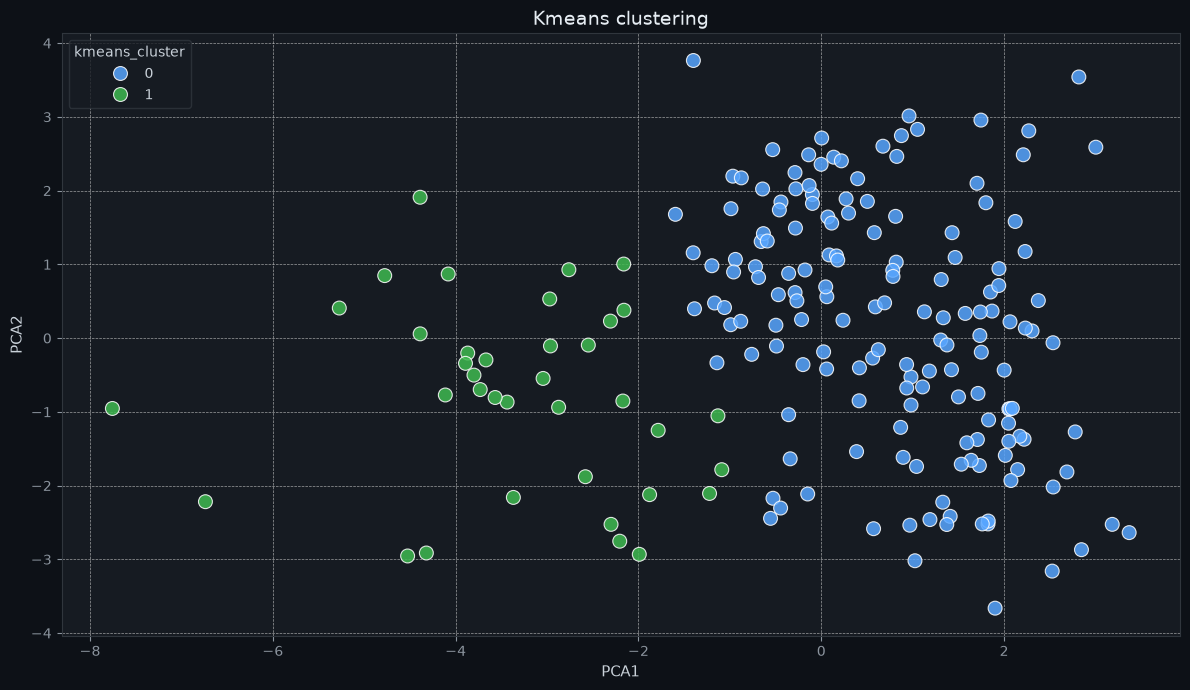

In [17]:
plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=X_pca_df,
    x="PCA1",
    y="PCA2",
    hue="kmeans_cluster",
    s=100,
    alpha=0.85
)
plt.title("Kmeans clustering")
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.tight_layout()
plt.show()

In [18]:
def objective_dbscan(trial: optuna.Trial) -> float:
    eps = trial.suggest_float("eps", 0.1, 2.0, step=0.05)
    min_samples = trial.suggest_int("min_samples", 3, 12)
    metric = trial.suggest_categorical(
        "metric", ["euclidean", "manhattan", "cosine"]
    )

    model = DBSCAN(
        eps=eps,
        min_samples=min_samples,
        metric=metric
    )
    labels = model.fit_predict(X_pca_df)

    n_clusters = len(set(labels)) - (1 if -1 in set(labels) else 0)
    noise_ration = np.sum(labels == -1) / len(labels)

    trial.set_user_attr("n_clusters", n_clusters)
    trial.set_user_attr("noise_ratio", round(noise_ration, 3))

    if n_clusters < 2:
        trial.set_user_attr("status", "Rejected (<2 members)")
        return -1

    if noise_ration > 0.2:
        trial.set_user_attr("status", "Rejected (>20 noise)")
        return -1

    mask = labels != 1
    score = silhouette_score(X_pca_df[mask], labels[mask])
    db_score = davies_bouldin_score(X_pca_df[mask], labels[mask])
    ch_score = calinski_harabasz_score(X_pca_df[mask], labels[mask])

    trial.set_user_attr("davies_bouldin", db_score)
    trial.set_user_attr("calinski_harabasz", ch_score)
    trial.set_user_attr("status", "Accepted")

    return score


study_dbscan = optuna.create_study(direction="maximize")
study_dbscan.optimize(
    objective_dbscan,
    n_trials=50,
    show_progress_bar=True
)

print("=" * 50)
print(f"Best silhouette score: {study_dbscan.best_value:.4f}")
print("Best hyperparameters:")
for key, value in study_dbscan.best_params.items():
    print(f"  - {key}: {value}")
print("=" * 50)

df_dbscan_results = study_dbscan.trials_dataframe()

cols = [
    "number", "value", "params_eps", "params_min_samples",
    "params_metric", "user_attrs_n_clusters",
    "user_attrs_noise_ratio", "user_attrs_davies_bouldin",
    "user_attrs_calinski_harabasz"
]

df_dbscan_summary = df_dbscan_results[cols].sort_values(by="value", ascending=False).reset_index(drop=True)
display(df_dbscan_summary.head(10))

best_dbscan = DBSCAN(**study_dbscan.best_params)
X_pca_df["dbscan_cluster"] = best_dbscan.fit_predict(X_pca_df)

Best trial: 47. Best value: 0.490719: 100%|██████████| 50/50 [00:00<00:00, 100.29it/s]


Best silhouette score: 0.4907
Best hyperparameters:
  - eps: 2.0
  - min_samples: 3
  - metric: manhattan


,number,value,params_eps,params_min_samples,params_metric,user_attrs_n_clusters,user_attrs_noise_ratio,user_attrs_davies_bouldin,user_attrs_calinski_harabasz
0,47,0.490719,2.00,3,manhattan,2,0.041,1.484244,23.313962
1,21,0.459098,1.95,4,manhattan,2,0.056,2.052679,17.362395
2,22,0.459098,2.00,4,manhattan,2,0.056,2.052679,17.362395
3,44,0.459098,2.00,4,manhattan,2,0.056,2.052679,17.362395
4,43,0.459098,2.00,4,manhattan,2,0.056,2.052679,17.362395
5,45,0.459098,1.95,4,manhattan,2,0.056,2.052679,17.362395
6,38,0.459098,2.00,4,manhattan,2,0.056,2.052679,17.362395
7,23,0.445563,1.95,5,manhattan,2,0.062,2.199400,16.302990
8,24,0.445563,1.95,5,manhattan,2,0.062,2.199400,16.302990
9,31,0.390889,1.90,5,manhattan,2,0.082,2.323929,16.514588


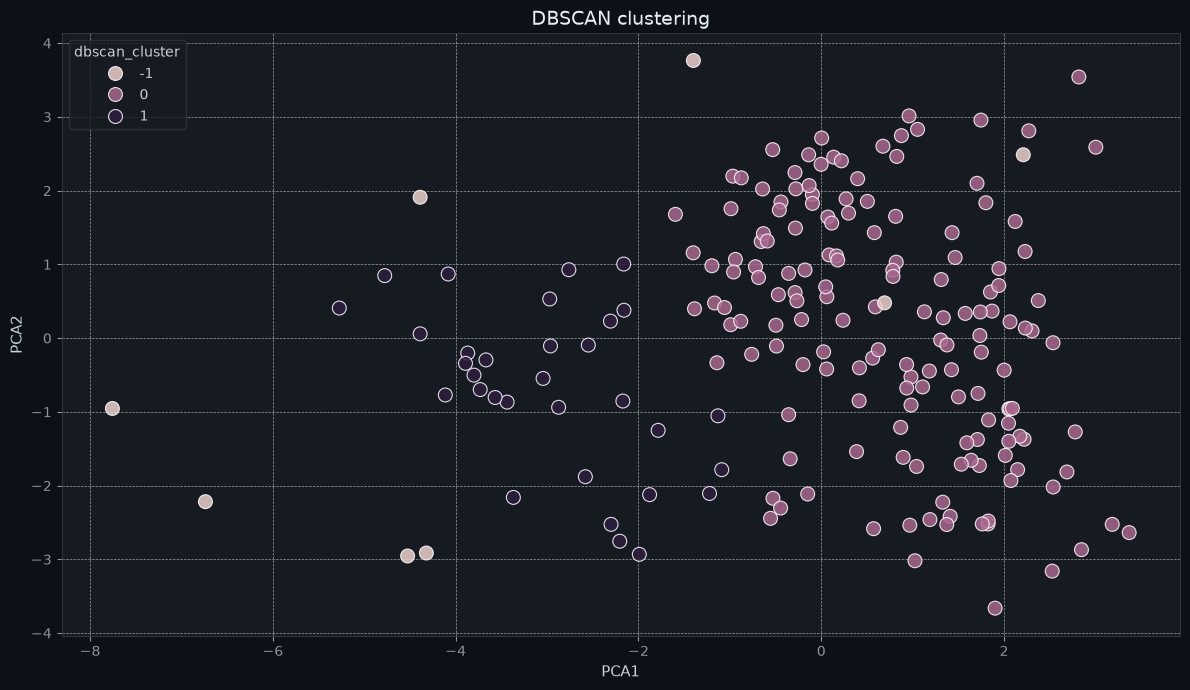

In [19]:
plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=X_pca_df,
    x="PCA1",
    y="PCA2",
    hue="dbscan_cluster",
    s=100,
    alpha=0.85
)
plt.title("DBSCAN clustering")
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.tight_layout()
plt.show()